# **Train Model**

In [101]:
import numpy as np
import cv2
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report, log_loss)
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
CSVPATH = PROJECT_ROOT / "feature_engineering" / "mango_defect.csv"

In [102]:
fruits = pd.read_csv(CSVPATH)
fruits

,image_id,image,brightness_threshold,defect_percentage,number_of_defects,yellow_ratio,largest_defect_ratio,mean_defect_ratio,aspect_ratio,circularity,solidity,grade
0,NDM_M1 (1),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,22,0.123682,4,70.826156,0.000532,0.000309,2.181001,0.599319,0.959423,NDM_M1
1,NDM_M1 (10),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,18,0.539316,16,68.416842,0.000828,0.000337,0.501448,0.624411,0.960154,NDM_M1
2,NDM_M1 (100),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.150871,6,72.215850,0.000532,0.000251,0.461047,0.572685,0.950932,NDM_M1
3,NDM_M1 (101),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,21,0.130499,4,83.939243,0.000451,0.000326,2.189017,0.600500,0.957417,NDM_M1
4,NDM_M1 (102),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,21,0.122899,4,83.936687,0.000435,0.000307,0.456509,0.602001,0.958129,NDM_M1
...,...,...,...,...,...,...,...,...,...,...,...,...
537,NDM_M3 (95),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.684021,15,0.125457,0.001503,0.000456,0.507673,0.684655,0.983823,NDM_M3
538,NDM_M3 (96),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,31,0.097857,4,0.322886,0.000499,0.000245,1.981343,0.678619,0.982263,NDM_M3
539,NDM_M3 (97),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,30,0.101622,4,0.358533,0.000514,0.000254,0.504391,0.681095,0.982601,NDM_M3
540,NDM_M3 (98),c:\Users\noppa\OneDrive\Desktop\mango\data\jpg...,20,0.075858,4,0.043647,0.000419,0.000190,1.809908,0.462822,0.952613,NDM_M3


In [103]:
grade_map = {"NDM_M1": "Class II",
             "NDM_M2": "Class I",
             "NDM_M3": "Extra Class"}

grades = fruits["grade"].map(grade_map)
fruits["grade"] = grades

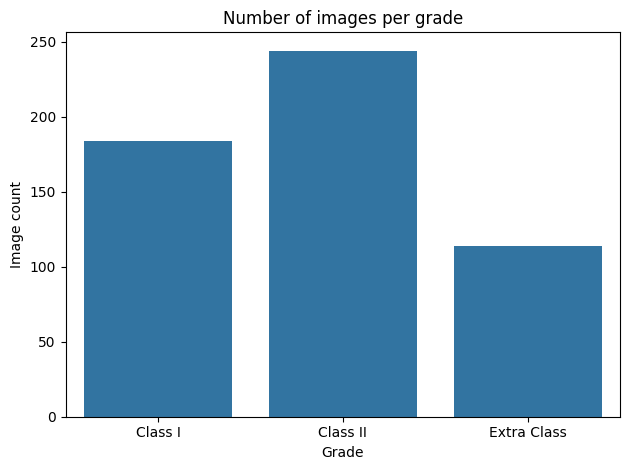

grade
Class I        184
Class II       244
Extra Class    114
Name: count, dtype: int64


In [104]:
grade_counts = fruits["grade"].value_counts().sort_index()

sns.countplot(data=fruits, x="grade", order=grade_counts.index)
plt.title("Number of images per grade")
plt.xlabel("Grade")
plt.ylabel("Image count")
plt.tight_layout()
plt.show()

print(grade_counts)

In [105]:
all_fruits = pd.read_csv(CSVPATH)
all_fruits["grade"] = all_fruits["grade"].map(grade_map)
if all_fruits["grade"].isna().any():
    raise ValueError("พบ grade ที่ไม่มีใน grade_map")

train_fruits, test_fruits = train_test_split(
    all_fruits,
    test_size=0.15,
    random_state=42,
    stratify=all_fruits["grade"],
)
fruits = train_fruits.reset_index(drop=True)
test_fruits = test_fruits.reset_index(drop=True)

X = fruits.drop(columns=["grade"])
y = fruits["grade"]
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

folds = []
for fold_number, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    train_data = fruits.iloc[train_idx].reset_index(drop=True)
    validation_data = fruits.iloc[val_idx].reset_index(drop=True)
    folds.append((train_data, validation_data))

    print(
        f"Fold {fold_number}: "
        f"train={len(train_data)}, validation={len(validation_data)}"
    )
    print("Train classes:", train_data["grade"].value_counts().to_dict())
    print("Validation classes:", validation_data["grade"].value_counts().to_dict())

train_ids = set(fruits["image_id"])
test_ids = set(test_fruits["image_id"])
if train_ids & test_ids:
    raise RuntimeError("Train/test image IDs overlap")

print(f"Training/CV images: {len(fruits)}")
print(f"Held-out test images: {len(test_fruits)}")
print("Test classes:", test_fruits["grade"].value_counts().to_dict())

Fold 1: train=368, validation=92
Train classes: {'Class II': 166, 'Class I': 124, 'Extra Class': 78}
Validation classes: {'Class II': 41, 'Class I': 32, 'Extra Class': 19}
Fold 2: train=368, validation=92
Train classes: {'Class II': 165, 'Class I': 125, 'Extra Class': 78}
Validation classes: {'Class II': 42, 'Class I': 31, 'Extra Class': 19}
Fold 3: train=368, validation=92
Train classes: {'Class II': 165, 'Class I': 125, 'Extra Class': 78}
Validation classes: {'Class II': 42, 'Class I': 31, 'Extra Class': 19}
Fold 4: train=368, validation=92
Train classes: {'Class II': 166, 'Class I': 125, 'Extra Class': 77}
Validation classes: {'Class II': 41, 'Class I': 31, 'Extra Class': 20}
Fold 5: train=368, validation=92
Train classes: {'Class II': 166, 'Class I': 125, 'Extra Class': 77}
Validation classes: {'Class II': 41, 'Class I': 31, 'Extra Class': 20}
Training/CV images: 460
Held-out test images: 82
Test classes: {'Class II': 37, 'Class I': 28, 'Extra Class': 17}


In [106]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset

FEATURE_COLUMNS = [
    "defect_percentage",
    "number_of_defects",
    "yellow_ratio",
    "largest_defect_ratio",
    "mean_defect_ratio",
    "aspect_ratio",
    "circularity",
    "solidity",
]
CLASS_NAMES = sorted(fruits["grade"].unique())
CLASS_TO_INDEX = {
    "Class II": 0,
    "Class I": 1,
    "Extra Class": 2}

train_data, validation_data = folds[0]
feature_scaler = StandardScaler()
feature_scaler.fit(train_data[FEATURE_COLUMNS])


class MangoDataset(Dataset):
    def __init__(self, frame, scaler):
        self.frame = frame.reset_index(drop=True)
        self.numeric_features = scaler.transform(
            self.frame[FEATURE_COLUMNS]
        ).astype(np.float32)
        self.labels = self.frame["grade"].map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = cv2.imread(str(row["image"]), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"ไม่พบภาพ: {row['image']}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_AREA)
        image = np.ascontiguousarray(image.transpose(2, 0, 1))
        image_tensor = torch.from_numpy(image).float() / 255.0

        feature_tensor = torch.from_numpy(self.numeric_features[index])
        label_tensor = torch.tensor(self.labels[index], dtype=torch.long)
        return image_tensor, feature_tensor, label_tensor


train_dataset = MangoDataset(train_data, feature_scaler)
validation_dataset = MangoDataset(validation_data, feature_scaler)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, num_workers=0)

images, numeric_features, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Numeric features:", numeric_features.shape)
print("Labels:", labels.shape)
print("Classes:", CLASS_TO_INDEX)

Images: torch.Size([32, 3, 224, 224])
Numeric features: torch.Size([32, 8])
Labels: torch.Size([32])
Classes: {'Class II': 0, 'Class I': 1, 'Extra Class': 2}


In [107]:
class CNNModule(nn.Module):
    def __init__(self, numeric_features, num_classes):
        super().__init__()
        self.backbone = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        for parameter in self.backbone.features.parameters():
            parameter.requires_grad = False
        self.backbone.classifier = nn.Identity()
        self.numeric_branch = nn.Sequential(
            nn.Linear(numeric_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
        )
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
        self.register_buffer(
            "image_mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "image_std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.backbone.features.eval()
        return self

    def forward(self, images, numeric_features):
        images = (images - self.image_mean) / self.image_std
        image_features = self.backbone(images)
        numeric_features = self.numeric_branch(numeric_features)
        combined = torch.cat((image_features, numeric_features), dim=1)
        return self.classifier(combined)


In [108]:
model = CNNModule(numeric_features=len(FEATURE_COLUMNS), num_classes=len(CLASS_TO_INDEX))
logits = model(images, numeric_features)
print(logits.shape)

torch.Size([32, 3])



Fold 1/5
Epoch 1/25 | train loss=1.0197, acc=0.573 | validation loss=0.9036, acc=0.717 | lr=0.001
Epoch 2/25 | train loss=0.8573, acc=0.717 | validation loss=0.7897, acc=0.707 | lr=0.001
Epoch 3/25 | train loss=0.7504, acc=0.734 | validation loss=0.7377, acc=0.696 | lr=0.001
Epoch 4/25 | train loss=0.6862, acc=0.736 | validation loss=0.7089, acc=0.717 | lr=0.001
Epoch 5/25 | train loss=0.6382, acc=0.745 | validation loss=0.6863, acc=0.685 | lr=0.001
Epoch 6/25 | train loss=0.6070, acc=0.758 | validation loss=0.6620, acc=0.739 | lr=0.001
Epoch 7/25 | train loss=0.5527, acc=0.777 | validation loss=0.6434, acc=0.717 | lr=0.001
Epoch 8/25 | train loss=0.5126, acc=0.818 | validation loss=0.6289, acc=0.728 | lr=0.001
Epoch 9/25 | train loss=0.4998, acc=0.829 | validation loss=0.6121, acc=0.728 | lr=0.001
Epoch 10/25 | train loss=0.4677, acc=0.842 | validation loss=0.5994, acc=0.750 | lr=0.001
Epoch 11/25 | train loss=0.4537, acc=0.832 | validation loss=0.6011, acc=0.750 | lr=0.001
Epoch 12/

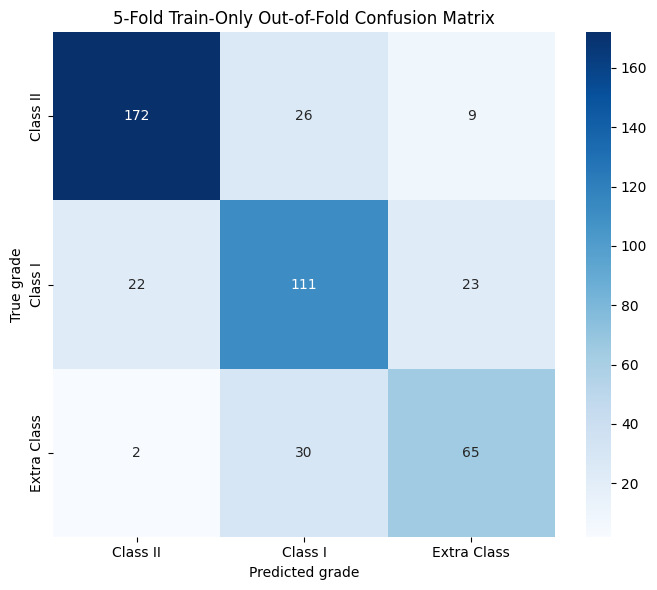

In [109]:
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
CV_MAX_EPOCHS = 25
CV_PATIENCE = 7
BATCH_SIZE = 32

out_of_fold_predictions = np.full(len(fruits), -1, dtype=np.int64)
out_of_fold_targets = fruits["grade"].map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)
fold_results = []

for fold_number, (train_indices, validation_indices) in enumerate(
    skf.split(X, y),
    start=1,
):
    print(f"\nFold {fold_number}/5")
    fold_train = fruits.iloc[train_indices].reset_index(drop=True)
    fold_validation = fruits.iloc[validation_indices].reset_index(drop=True)

    fold_scaler = StandardScaler()
    fold_scaler.fit(fold_train[FEATURE_COLUMNS])
    fold_train_dataset = MangoDataset(fold_train, fold_scaler)
    fold_validation_dataset = MangoDataset(fold_validation, fold_scaler)

    loader_generator = torch.Generator().manual_seed(42 + fold_number)
    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator,
    )
    fold_validation_loader = DataLoader(
        fold_validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    torch.manual_seed(42 + fold_number)
    fold_model = CNNModule(
        numeric_features=len(FEATURE_COLUMNS),
        num_classes=len(CLASS_TO_INDEX),
    ).to(device)

    fold_class_counts = fold_train["grade"].value_counts()
    fold_class_weights = torch.tensor(
        [
            len(fold_train) / (len(CLASS_TO_INDEX) * fold_class_counts[class_name])
            for class_name, _ in sorted(CLASS_TO_INDEX.items(), key=lambda item: item[1])
        ],
        dtype=torch.float32,
        device=device,
    )
    fold_criterion = nn.CrossEntropyLoss(weight=fold_class_weights)
    fold_optimizer = torch.optim.AdamW(
        (parameter for parameter in fold_model.parameters() if parameter.requires_grad),
        lr=1e-3,
        weight_decay=1e-4,
    )
    fold_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        fold_optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
    )

    def run_fold_epoch(loader, training):
        fold_model.train(training)
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        with torch.set_grad_enabled(training):
            for batch_images, batch_features, batch_labels in loader:
                batch_images = batch_images.to(device)
                batch_features = batch_features.to(device)
                batch_labels = batch_labels.to(device)

                if training:
                    fold_optimizer.zero_grad(set_to_none=True)

                batch_logits = fold_model(batch_images, batch_features)
                batch_loss = fold_criterion(batch_logits, batch_labels)

                if training:
                    batch_loss.backward()
                    fold_optimizer.step()

                batch_size = batch_labels.size(0)
                total_loss += batch_loss.item() * batch_size
                total_correct += (batch_logits.argmax(dim=1) == batch_labels).sum().item()
                total_samples += batch_size

        return total_loss / total_samples, total_correct / total_samples

    best_fold_loss = float("inf")
    best_fold_state = None
    best_fold_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(CV_MAX_EPOCHS):
        train_loss, train_accuracy = run_fold_epoch(fold_train_loader, training=True)
        validation_loss, validation_accuracy = run_fold_epoch(
            fold_validation_loader,
            training=False,
        )
        fold_scheduler.step(validation_loss)
        current_lr = fold_optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1}/{CV_MAX_EPOCHS} | "
            f"train loss={train_loss:.4f}, acc={train_accuracy:.3f} | "
            f"validation loss={validation_loss:.4f}, acc={validation_accuracy:.3f} | "
            f"lr={current_lr:.2g}"
        )

        if validation_loss < best_fold_loss:
            best_fold_loss = validation_loss
            best_fold_epoch = epoch + 1
            best_fold_state = {
                key: value.detach().cpu().clone()
                for key, value in fold_model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= CV_PATIENCE:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    fold_model.load_state_dict(best_fold_state)
    fold_model.eval()
    fold_predictions = []

    with torch.no_grad():
        for batch_images, batch_features, _ in fold_validation_loader:
            batch_logits = fold_model(batch_images.to(device), batch_features.to(device))
            fold_predictions.extend(batch_logits.argmax(dim=1).cpu().numpy())

    out_of_fold_predictions[validation_indices] = fold_predictions
    fold_accuracy = accuracy_score(
        out_of_fold_targets[validation_indices],
        fold_predictions,
    )
    fold_f1 = f1_score(
        out_of_fold_targets[validation_indices],
        fold_predictions,
        labels=list(range(len(CLASS_TO_INDEX))),
        average="macro",
        zero_division=0,
    )
    fold_results.append(
        {
            "fold": fold_number,
            "best_epoch": best_fold_epoch,
            "best_validation_loss": best_fold_loss,
            "accuracy": fold_accuracy,
            "macro_f1": fold_f1,
        }
    )
    print(
        f"Best fold {fold_number}: epoch={best_fold_epoch}, "
        f"val loss={best_fold_loss:.4f}, accuracy={fold_accuracy:.4f}, "
        f"macro F1={fold_f1:.4f}"
    )

if np.any(out_of_fold_predictions < 0):
    raise RuntimeError("Some training samples did not receive an out-of-fold prediction")

class_names_by_index = [
    name for name, _ in sorted(CLASS_TO_INDEX.items(), key=lambda item: item[1])
]
class_indices = list(range(len(class_names_by_index)))

print("\nTrain-only out-of-fold classification report:")
print(classification_report(
    out_of_fold_targets,
    out_of_fold_predictions,
    labels=class_indices,
    target_names=class_names_by_index,
    digits=4,
    zero_division=0,
))

fold_summary = pd.DataFrame(fold_results)
print("Fold summary:")
print(fold_summary)
print("Mean fold accuracy:", f"{fold_summary['accuracy'].mean():.4f}")
print("Mean fold macro F1:", f"{fold_summary['macro_f1'].mean():.4f}")

cv_matrix = confusion_matrix(
    out_of_fold_targets,
    out_of_fold_predictions,
    labels=class_indices,
)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cv_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_by_index,
    yticklabels=class_names_by_index,
    ax=ax,
)
ax.set_xlabel("Predicted grade")
ax.set_ylabel("True grade")
ax.set_title("5-Fold Train-Only Out-of-Fold Confusion Matrix")
plt.tight_layout()
plt.show()

Final training epochs from CV median: 16
Final train epoch 1/16 | loss=1.0265
Final train epoch 2/16 | loss=0.8612
Final train epoch 3/16 | loss=0.7584
Final train epoch 4/16 | loss=0.7071
Final train epoch 5/16 | loss=0.6541
Final train epoch 6/16 | loss=0.5835
Final train epoch 7/16 | loss=0.5450
Final train epoch 8/16 | loss=0.5076
Final train epoch 9/16 | loss=0.5092
Final train epoch 10/16 | loss=0.4900
Final train epoch 11/16 | loss=0.4770
Final train epoch 12/16 | loss=0.4367
Final train epoch 13/16 | loss=0.4006
Final train epoch 14/16 | loss=0.3833
Final train epoch 15/16 | loss=0.3860
Final train epoch 16/16 | loss=0.3780
Held-out test classification report:
              precision    recall  f1-score   support

    Class II     0.9091    0.8108    0.8571        37
     Class I     0.6286    0.7857    0.6984        28
 Extra Class     0.6429    0.5294    0.5806        17

    accuracy                         0.7439        82
   macro avg     0.7268    0.7086    0.7121        

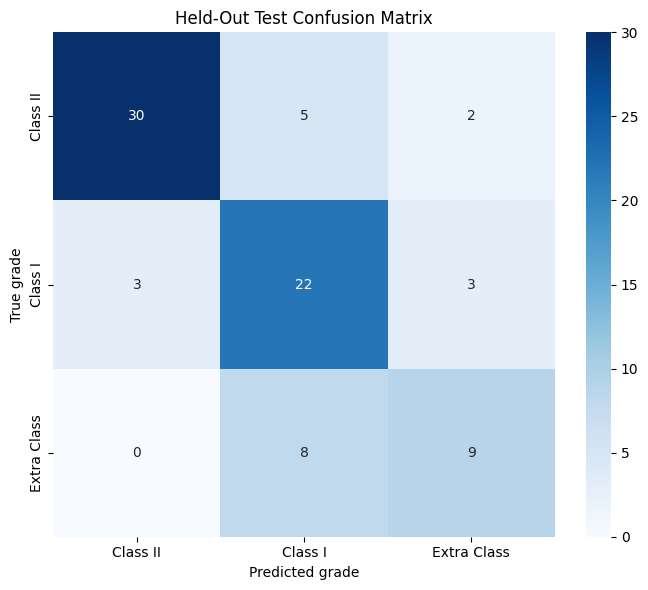

Saved final model to: c:\Users\noppa\OneDrive\Desktop\mango\training\mango_multimodal_mobilenet_v2.pth


In [110]:
FINAL_EPOCHS = max(1, int(round(fold_summary["best_epoch"].median())))
print(f"Final training epochs from CV median: {FINAL_EPOCHS}")

final_scaler = StandardScaler()
final_scaler.fit(fruits[FEATURE_COLUMNS])
final_train_dataset = MangoDataset(fruits, final_scaler)
final_test_dataset = MangoDataset(test_fruits, final_scaler)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(2026),
)
final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

torch.manual_seed(2026)
final_model = CNNModule(
    numeric_features=len(FEATURE_COLUMNS),
    num_classes=len(CLASS_TO_INDEX),
).to(device)

final_class_counts = fruits["grade"].value_counts()
final_class_weights = torch.tensor(
    [
        len(fruits) / (len(CLASS_TO_INDEX) * final_class_counts[class_name])
        for class_name, _ in sorted(CLASS_TO_INDEX.items(), key=lambda item: item[1])
    ],
    dtype=torch.float32,
    device=device,
)
final_criterion = nn.CrossEntropyLoss(weight=final_class_weights)
final_optimizer = torch.optim.AdamW(
    (parameter for parameter in final_model.parameters() if parameter.requires_grad),
    lr=1e-3,
    weight_decay=1e-4,
)

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    total_loss = 0.0
    total_samples = 0

    for batch_images, batch_features, batch_labels in final_train_loader:
        batch_images = batch_images.to(device)
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        final_optimizer.zero_grad(set_to_none=True)
        logits = final_model(batch_images, batch_features)
        loss = final_criterion(logits, batch_labels)
        loss.backward()
        final_optimizer.step()

        batch_size = batch_labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    print(
        f"Final train epoch {epoch + 1}/{FINAL_EPOCHS} | "
        f"loss={total_loss / total_samples:.4f}"
    )

FINAL_MODEL_PATH = PROJECT_ROOT / "training" / "mango_multimodal_mobilenet_v2.pth"
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "class_to_index": CLASS_TO_INDEX,
        "feature_columns": FEATURE_COLUMNS,
        "feature_mean": final_scaler.mean_,
        "feature_scale": final_scaler.scale_,
        "final_epochs": FINAL_EPOCHS,
    },
    FINAL_MODEL_PATH,
)

final_model.eval()
test_targets = []
test_predictions = []
with torch.no_grad():
    for batch_images, batch_features, batch_labels in final_test_loader:
        logits = final_model(batch_images.to(device), batch_features.to(device))
        test_predictions.extend(logits.argmax(dim=1).cpu().numpy())
        test_targets.extend(batch_labels.numpy())

print("Held-out test classification report:")
print(classification_report(
    test_targets,
    test_predictions,
    labels=class_indices,
    target_names=class_names_by_index,
    digits=4,
    zero_division=0,
))

test_matrix = confusion_matrix(
    test_targets,
    test_predictions,
    labels=class_indices,
)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    test_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_by_index,
    yticklabels=class_names_by_index,
    ax=ax,
)
ax.set_xlabel("Predicted grade")
ax.set_ylabel("True grade")
ax.set_title("Held-Out Test Confusion Matrix")
plt.tight_layout()
plt.show()
print(f"Saved final model to: {FINAL_MODEL_PATH}")

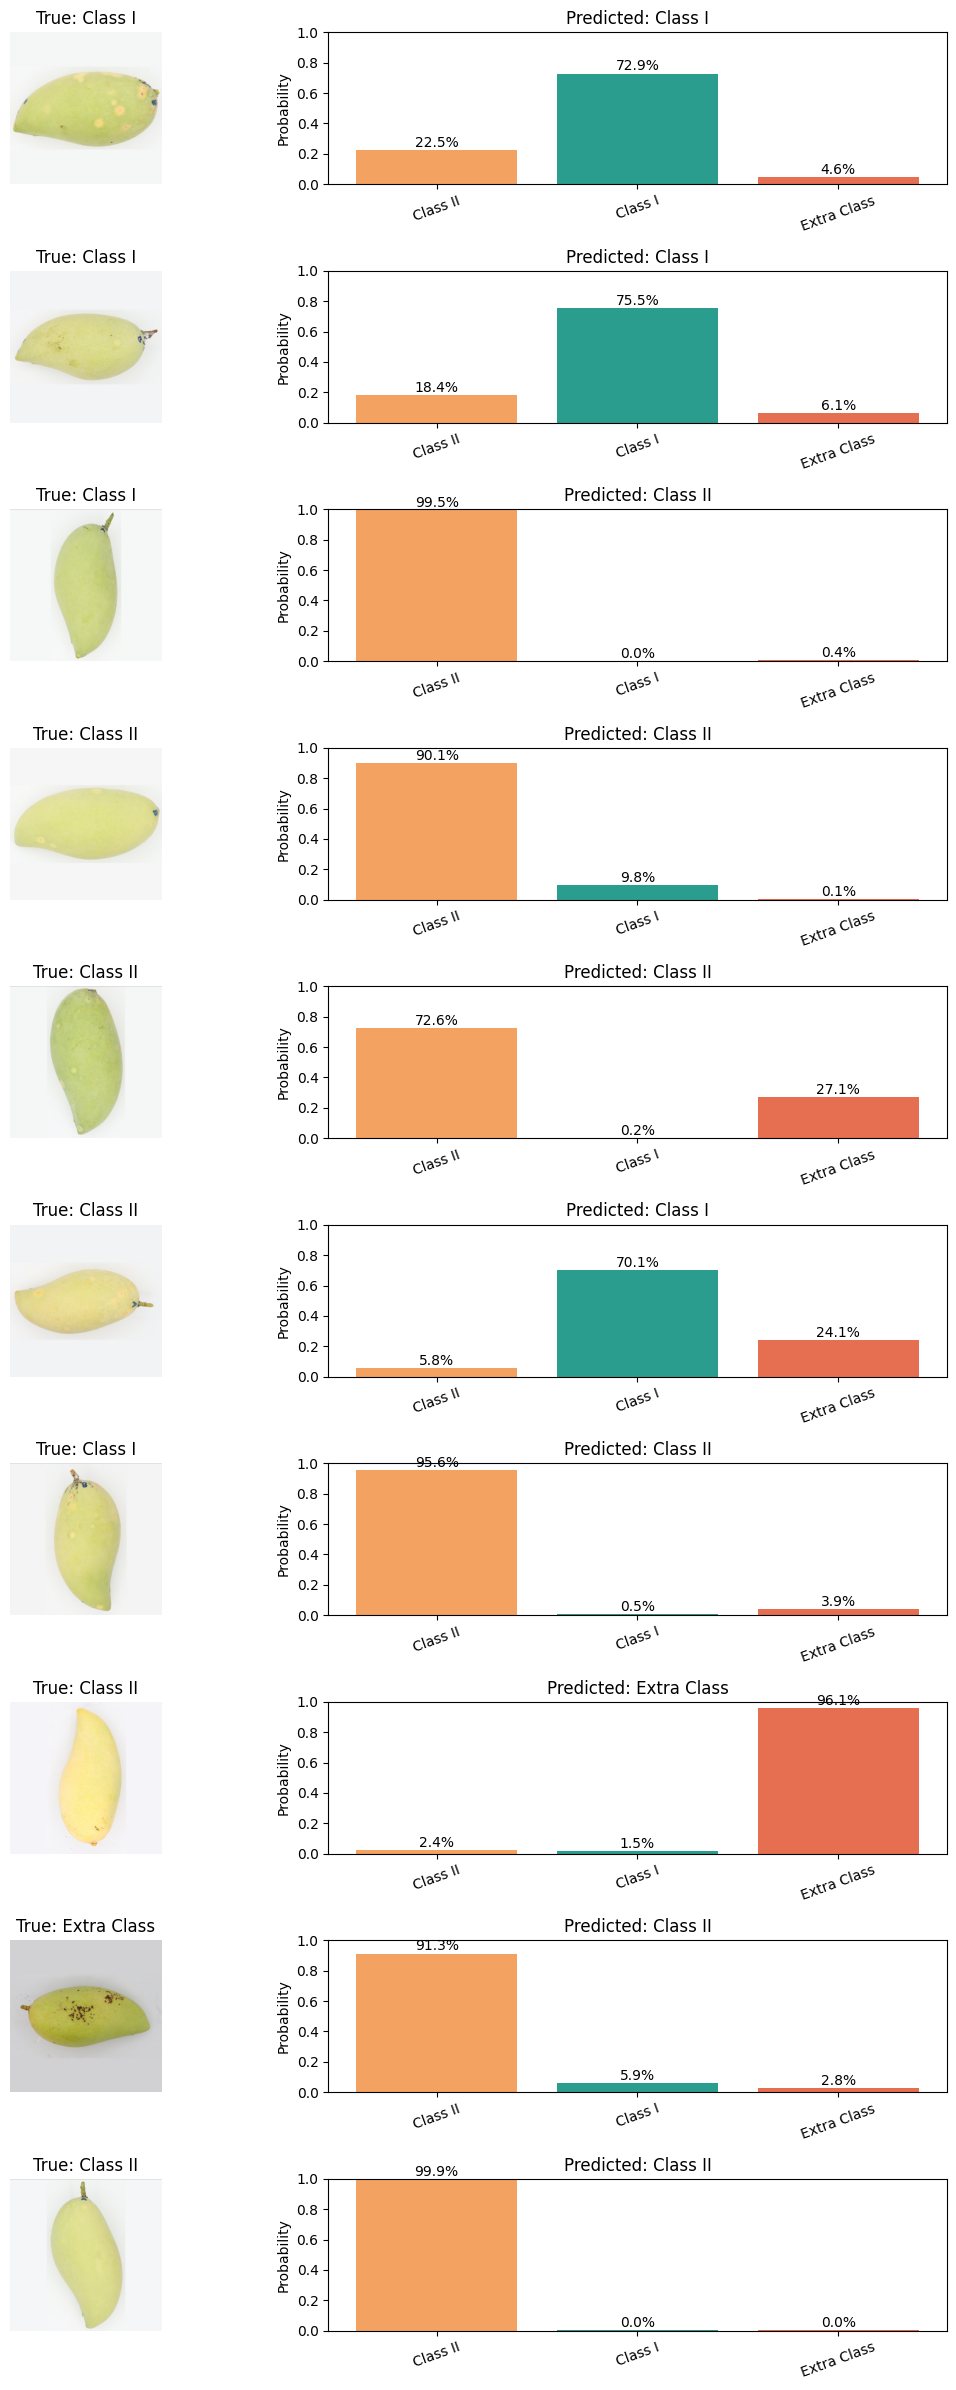

In [113]:
import random

fig, ax = plt.subplots(10, 2, figsize=(12, 24))
for i in range(10):
    sampled_test_idx = random.randint(0, len(test_fruits) - 1)
    sampled_test_fruit = test_fruits.iloc[sampled_test_idx]
    fruit_img = plt.imread(str(sampled_test_fruit['image']))
    ax[i][0].imshow(fruit_img)
    ax[i][0].axis('off')
    ax[i][0].set_title(f'True: {predicted_class}')

    image_tensor, feature_tensor, _ = final_test_dataset[sampled_test_idx]
    with torch.no_grad():
        logits = final_model(
            image_tensor.unsqueeze(0).to(device),
            feature_tensor.unsqueeze(0).to(device),
        )
        probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    predicted_class = class_names_by_index[int(probabilities.argmax())]
    ax[i][1].bar(class_names_by_index, probabilities, color=['#F4A261', '#2A9D8F', '#E76F51'])
    ax[i][1].set_ylim(0, 1)
    ax[i][1].set_ylabel('Probability')
    ax[i][1].set_title(f'Predicted: {predicted_class}')
    ax[i][1].tick_params(axis='x', rotation=20)
    for grade, probability in zip(class_names_by_index, probabilities):
        ax[i][1].text(grade, probability + 0.02, f'{probability:.1%}', ha='center')

plt.tight_layout()
plt.show()